<a href="https://colab.research.google.com/github/haqiaryva/UTS-DeepLearning/blob/main/Studi_Kasus_2_HOG_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import matplotlib.pyplot as plt
import cv2
from numpy.linalg import norm
import datetime
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import cross_val_score

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

EDA

In [ ]:
print(f"Training data size is {train.shape}\nTesting data size is {test.shape}")

Training data size is (13766, 785)
Testing data size is (18381, 784)


In [5]:
X = train.drop(['label'], axis=1).values
y = train['label'].values

In [6]:
X = X / 255.0

In [7]:
X = X.reshape(-1,28,28,1)

In [9]:

y = to_categorical(y)

print(f"Label size {y.shape}")

Label size (13766, 10)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12389, 28, 28, 1), (1377, 28, 28, 1), (12389, 10), (1377, 10))

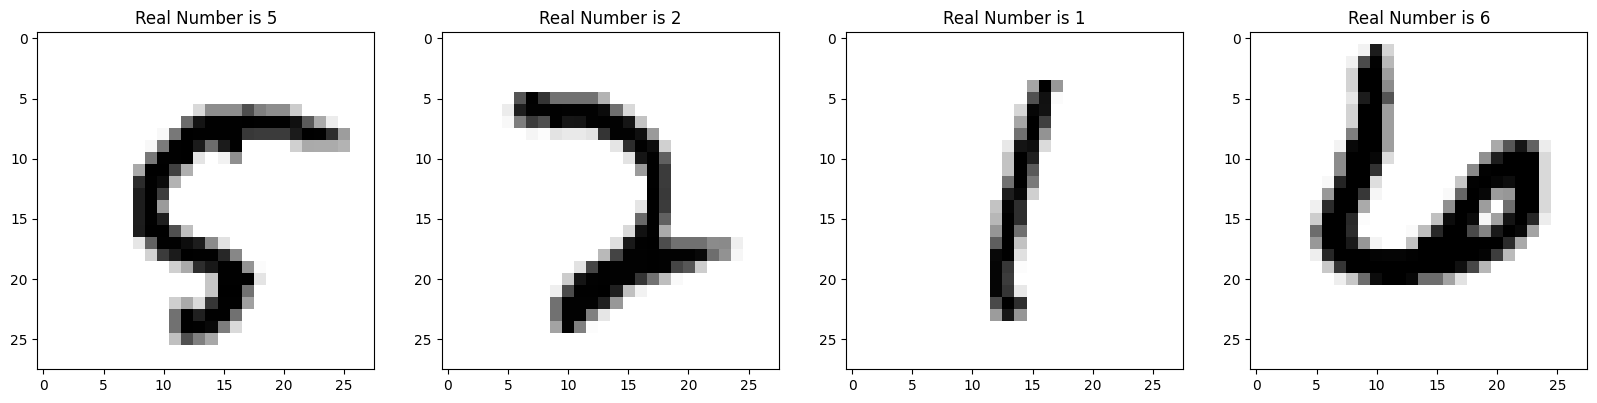

In [13]:
X_train__ = X_train.reshape(X_train.shape[0], 28, 28)

fig, axis = plt.subplots(1, 4, figsize=(20, 10))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_train__[i], cmap='binary')
    digit = y_train[i].argmax()
    ax.set(title = f"Real Number is {digit}");

In [14]:
mean = np.mean(X_train)
std = np.std(X_train)

def standardize(x):
    return (x-mean)/std

HOG SVM

In [19]:
def HOG(imgs):
    hog = cv2.HOGDescriptor((28,28),(8,8),(4,4),(8,8),9,1,-1,0,0.1,1,32, True)
    hog_descriptors = []
    for img in imgs:
        # Ensure no NaNs and clip values to [0, 1] range before scaling to 0-255
        img_cleaned = np.nan_to_num(img)
        cv_img = np.around(np.clip(img_cleaned * 255, 0, 255)).astype('uint8')
        hog_descriptors.append(hog.compute(cv_img))

    hog_descriptors = np.squeeze(hog_descriptors)
    return hog_descriptors

In [17]:
X_train_hog = HOG(X_train.reshape(-1, 28, 28))
X_test_hog = HOG(X_test.reshape(-1, 28, 28))

y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print(f"HOG Features shape: {X_train_hog.shape}")

/tmp/ipykernel_7753/1477227576.py:5: RuntimeWarning: invalid value encountered in cast
  cv_img = np.around(img*255).astype('uint8')


HOG Features shape: (12389, 324)


In [18]:
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X_train_hog, y_train_labels)

y_pred = clf.predict(X_test_hog)

accuracy = accuracy_score(y_test_labels, y_pred)
print(f"SVM Accuracy with HOG features: {accuracy * 100:.2f}%")

SVM Accuracy with HOG features: 98.33%


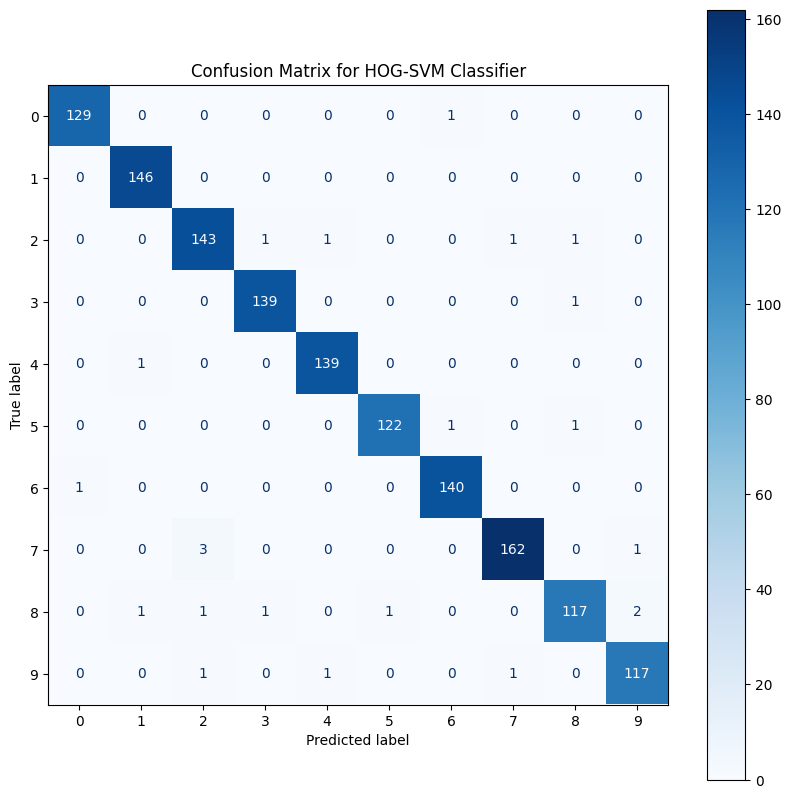

In [20]:
cm = confusion_matrix(y_test_labels, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix for HOG-SVM Classifier')
plt.show()